In [1]:
from pathlib import Path
from tqdm import tqdm
import math
import torch
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset, concatenate_datasets, Dataset
from tokenizers import Tokenizer
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
wikimatrix = load_dataset("sentence-transformers/parallel-sentences-wikimatrix", "en-zh")["train"]
opensubtitles = load_dataset("sentence-transformers/parallel-sentences-opensubtitles", "en-zh_cn")["train"]
talks = load_dataset("sentence-transformers/parallel-sentences-talks", "en-zh-cn")["train"]
tatoeba = load_dataset("sentence-transformers/parallel-sentences-tatoeba", "en-zh")["train"]
# ccmatrix = load_dataset("sentence-transformers/parallel-sentences-ccmatrix", "en-zh")["train"]

raw_dataset = concatenate_datasets([wikimatrix, opensubtitles, talks, tatoeba])

Resolving data files:   0%|          | 0/23 [00:00<?, ?it/s]

In [3]:
def dataset_processing(dataset: Dataset, squence_length: int = 512):
    def chinese_rule(code: int):
        return code < 128 or 0x4E00 <= code <= 0x9FFF or 0x3000 <= code <= 0x303F or 0xFF01 <= code <= 0xFF5E

    def english_rule(code: int):
        return code < 128 or 0x3000 <= code <= 0x303F or 0xFF01 <= code <= 0xFF5E

    squence_length = squence_length - 2

    en_list: list[str] = []
    zh_list: list[str] = []
    for data in tqdm(dataset, desc="pre-processing"):
        en = data["english"]
        zh = data["non_english"]
        if len(en) > squence_length or len(zh) > squence_length:
            continue
        if all([english_rule(ord(c)) for c in en]) and all([chinese_rule(ord(c)) for c in zh]):
            en_list.append(en)
            zh_list.append(zh)
    print(f"训练句对长度: {len(en_list)}")
    return en_list, zh_list


en_list, zh_list = dataset_processing(raw_dataset)

en_tokenizer_path = Path("en_tokenizer.json")
zh_tokenizer_path = Path("zh_tokenizer.json")

if en_tokenizer_path.exists() and zh_tokenizer_path.exists():
    en_tokenizer = Tokenizer.from_file(en_tokenizer_path.as_posix())
    zh_tokenizer = Tokenizer.from_file(zh_tokenizer_path.as_posix())
else:

    from tokenizers import models, trainers, pre_tokenizers

    en_vocab_size = 25000
    zh_vocab_size = 25000
    min_frequency = 2

    special_tokens = ["[PAD]", "[UNK]", "[SOS]", "[EOS]"]
    continuing_subword_prefix = "##"
    # 英文分词器
    en_tokenizer = Tokenizer(models.WordPiece(unk_token="[UNK]"))
    en_tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()
    en_trainer = trainers.WordPieceTrainer(
        vocab_size=en_vocab_size,
        min_frequency=min_frequency,
        special_tokens=special_tokens + [".", ",", "!", "?", ";", ":"],
        continuing_subword_prefix=continuing_subword_prefix,
    )
    en_tokenizer.train_from_iterator(en_list, trainer=en_trainer)
    # 中文分词器
    zh_tokenizer = Tokenizer(models.WordPiece(unk_token="[UNK]"))
    zh_trainer = trainers.WordPieceTrainer(
        vocab_size=zh_vocab_size,
        min_frequency=min_frequency,
        special_tokens=special_tokens + [".", ",", "!", "?", ";", ":"] + [chr(i) for i in range(0x3000, 0x303F)],
        continuing_subword_prefix=continuing_subword_prefix,
    )
    zh_tokenizer.train_from_iterator(zh_list, trainer=zh_trainer)
    # 处理文本编码
    en_tokenizer.save(en_tokenizer_path.as_posix())
    zh_tokenizer.save(zh_tokenizer_path.as_posix())

PAD, UNK, SOS, EOS = 0, 1, 2, 3
assert en_tokenizer.token_to_id("[PAD]") == zh_tokenizer.token_to_id("[PAD]") == PAD
assert en_tokenizer.token_to_id("[UNK]") == zh_tokenizer.token_to_id("[UNK]") == UNK
assert en_tokenizer.token_to_id("[SOS]") == zh_tokenizer.token_to_id("[SOS]") == SOS
assert en_tokenizer.token_to_id("[EOS]") == zh_tokenizer.token_to_id("[EOS]") == EOS

en_dataset = [torch.tensor([SOS] + en_tokenizer.encode(text).ids + [EOS], device=DEVICE) for text in tqdm(en_list, desc="build en")]
zh_dataset = [torch.tensor([SOS] + zh_tokenizer.encode(text).ids + [EOS], device=DEVICE) for text in tqdm(zh_list, desc="build zh")]
dataset = [(en, zh) for en, zh in zip(en_dataset, zh_dataset)]

pre-processing: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 874236/874236 [00:26<00:00, 32493.47it/s]


训练句对长度: 794938


build zh: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 794938/794938 [01:17<00:00, 10229.83it/s]


In [4]:
def train(
    model: torch.nn.Module,
    loader: DataLoader,
    num_epochs=10,
    lr: float = 0.001,
    save_path: Path | None = None,
    lossi: list | None = None,
):
    print("模型参数：", sum(p.numel() for p in model.parameters() if p.requires_grad))
    model.train()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    criterion = torch.nn.CrossEntropyLoss(ignore_index=PAD)
    lossi = [] if lossi is None else lossi
    for epoch in range(num_epochs):
        for inputs, targets in tqdm(loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            loss = criterion(model.forward(inputs, targets[:, :-1]).transpose(-2, -1), targets[:, 1:])
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            lossi.append(loss.item())
        print(f"Current Loss {lossi[-1]:.4f}")
        if save_path is not None:
            torch.save(model, save_path / f"model{epoch+1}.pth")
        torch.cuda.empty_cache()
    return lossi

In [5]:
class FeedForward(torch.nn.Module):

    def __init__(self, emb_size: int):
        super().__init__()
        self.lm1 = torch.nn.Linear(emb_size, 4 * emb_size)
        self.lm2 = torch.nn.Linear(4 * emb_size, emb_size)
        self.dp = torch.nn.Dropout(0.4)

    def forward(self, x: torch.Tensor):
        out = torch.nn.functional.gelu(self.lm1(x))
        out = self.dp(self.lm2(out))
        return out


class SelfMultiHeadAttention(torch.nn.Module):
    def __init__(self, emb_size: int, head_size: int):
        assert emb_size % head_size == 0
        super().__init__()
        self.qkv_linear = torch.nn.Linear(emb_size, emb_size * 3, bias=False)
        self.proj = torch.nn.Linear(emb_size, emb_size)
        self.dp = torch.nn.Dropout(0.4)
        # 其他参数
        self.n_head = emb_size // head_size
        self.head_size = head_size
        self.scale = self.head_size**-0.5

    def forward(self, x: torch.Tensor, mask: torch.Tensor | None = None):
        q, k, v = self.qkv_linear.forward(x).chunk(3, dim=-1)
        # 把 q, v 的形状从 (B, T, emb_size) 变为 (B, n_head, T, head_size)
        # 把 k 的形状从 (B, T, emb_size) 变为 (B, n_head, head_size, T)
        q = q.unflatten(dim=-1, sizes=(self.n_head, self.head_size)).transpose(-3, -2)
        k = k.transpose(-2, -1).unflatten(dim=-2, sizes=(self.n_head, self.head_size))
        v = v.unflatten(dim=-1, sizes=(self.n_head, self.head_size)).transpose(-3, -2)
        scores = (q @ k) * self.scale
        scores = scores.masked_fill(mask, float("-inf"))
        w_att = scores.softmax(dim=-1).masked_fill(mask, 0)
        # 此时 attn_output 的形状为 (B, n_head, T, head_size)
        attn_output = w_att @ v
        # 恢复 attn_output 的形状为 (B, T, emb_size)
        attn_output = attn_output.transpose(-3, -2).flatten(start_dim=-2)
        mha = self.dp(self.proj(attn_output))
        return mha


class CrossMultiHeadAttention(torch.nn.Module):
    def __init__(self, emb_size: int, head_size: int):
        assert emb_size % head_size == 0
        super().__init__()
        self.kv_linear = torch.nn.Linear(emb_size, emb_size * 2, bias=False)
        self.q_linear = torch.nn.Linear(emb_size, emb_size, bias=False)
        self.proj = torch.nn.Linear(emb_size, emb_size)
        self.dp = torch.nn.Dropout(0.4)
        # 其他参数
        self.n_head = emb_size // head_size
        self.head_size = head_size
        self.scale = self.head_size**-0.5

    def forward(self, x: torch.Tensor, y: torch.Tensor, mask: torch.Tensor):
        k, v = self.kv_linear.forward(y).chunk(2, dim=-1)
        q = self.q_linear.forward(x)
        q = q.unflatten(dim=-1, sizes=(self.n_head, self.head_size)).transpose(-3, -2)
        k = k.transpose(-2, -1).unflatten(dim=-2, sizes=(self.n_head, self.head_size))
        v = v.unflatten(dim=-1, sizes=(self.n_head, self.head_size)).transpose(-3, -2)
        scores = (q @ k) * self.scale
        scores = scores.masked_fill(mask, float("-inf"))
        w_att = scores.softmax(dim=-1).masked_fill(mask, 0)
        attn_output = w_att @ v
        attn_output = attn_output.transpose(-3, -2).flatten(start_dim=-2)
        mha = self.dp(self.proj(attn_output))
        return mha


class EncoderBlock(torch.nn.Module):
    def __init__(self, emb_size: int, head_size: int):
        super().__init__()
        self.mha_ln = torch.nn.LayerNorm(emb_size)
        self.mha = SelfMultiHeadAttention(emb_size, head_size)
        self.ff_ln = torch.nn.LayerNorm(emb_size)
        self.ff = FeedForward(emb_size)

    def forward(self, x: torch.Tensor, mask: torch.Tensor):
        x = x + self.mha(self.mha_ln(x), mask)
        x = x + self.ff(self.ff_ln(x))
        return x


class DecoderBlock(torch.nn.Module):
    def __init__(self, emb_size: int, head_size: int):
        super().__init__()
        self.mha_ln = torch.nn.LayerNorm(emb_size)
        self.mha = SelfMultiHeadAttention(emb_size, head_size)
        self.cross_mha_ln = torch.nn.LayerNorm(emb_size)
        self.cross_mha = CrossMultiHeadAttention(emb_size, head_size)
        self.ff_ln = torch.nn.LayerNorm(emb_size)
        self.ff = FeedForward(emb_size)

    def forward(self, x: torch.Tensor, y: torch.Tensor, self_mask: torch.Tensor, cross_mask: torch.Tensor):
        x = x + self.mha(self.mha_ln(x), self_mask)
        x = x + self.cross_mha(self.cross_mha_ln(x), y, cross_mask)
        x = x + self.ff(self.ff_ln(x))
        return x


class TransformerEDM(torch.nn.Module):
    def __init__(
        self,
        enc_vs: int,
        dec_vs: int,
        emb_size: int,
        head_size: int,
        n_block: int,
        sequence_length: int,
        padding_idx: int = 0,
    ):
        super().__init__()
        # 编码器
        self.enc_blocks = torch.nn.ModuleList()
        # 解码器
        self.dec_blocks = torch.nn.ModuleList()
        self.blocks = [(EncoderBlock(emb_size, head_size), DecoderBlock(emb_size, head_size)) for _ in range(n_block)]
        for enc_block, dec_block in self.blocks:
            self.enc_blocks.append(enc_block)
            self.dec_blocks.append(dec_block)
        self.ln = torch.nn.LayerNorm(emb_size)
        # 编码器词嵌入
        self.enc_token_emb = torch.nn.Embedding(enc_vs, emb_size)
        self.enc_position_emb = torch.nn.Embedding(sequence_length, emb_size)
        # 解码器词嵌入
        self.dec_token_emb = torch.nn.Embedding(dec_vs, emb_size)
        self.dec_position_emb = torch.nn.Embedding(sequence_length, emb_size)
        # 解码器输出层
        self.dec_lm = torch.nn.Linear(emb_size, dec_vs)

        # 下面是其他属性
        self.mask: torch.Tensor
        self.register_buffer("mask", ~torch.tril(torch.ones(sequence_length, sequence_length, dtype=torch.bool)))
        self.position: torch.Tensor
        self.register_buffer("position", torch.arange(0, sequence_length, dtype=torch.long))
        self.padding_idx = padding_idx

    def forward(self, x: torch.Tensor, y: torch.Tensor):
        Tx = x.size(-1)
        Ty = y.size(-1)
        # 词嵌入和位置编码
        enc_inputs: torch.Tensor = self.enc_token_emb(x) + self.enc_position_emb(self.position[:Tx])
        dec_inputs: torch.Tensor = self.dec_token_emb(y) + self.dec_position_emb(self.position[:Ty])
        # 掩码处理
        x_padding_mask = x == self.padding_idx
        y_padding_mask = y == self.padding_idx
        enc_self_mask = (x_padding_mask.unsqueeze(-2) | x_padding_mask.unsqueeze(-1)).unsqueeze(-3)
        dec_self_mask = y_padding_mask.unsqueeze(-2) | y_padding_mask.unsqueeze(-1)
        dec_self_mask = (dec_self_mask | self.mask[:Ty, :Ty]).unsqueeze(-3)
        dec_cross_mask = x_padding_mask.unsqueeze(-2).unsqueeze(-2)
        # 多层编解码器
        for enc_block, dec_block in self.blocks:
            enc_inputs = enc_block(enc_inputs, enc_self_mask)
            dec_inputs = dec_block(dec_inputs, enc_inputs, dec_self_mask, dec_cross_mask)
        out = self.dec_lm(self.ln(dec_inputs))
        return out

In [150]:
model_file = Path("model.pth")
if model_file.exists():
    model = torch.load(model_file, weights_only=False).to(DEVICE)
else:
    model = TransformerEDM(
        enc_vs=en_tokenizer.get_vocab_size(),
        dec_vs=zh_tokenizer.get_vocab_size(),
        emb_size=128,
        head_size=32,
        n_block=4,
        sequence_length=512,
    ).to(DEVICE)

In [7]:
def collate_fn(batch):
    en_batch, zh_batch = zip(*batch)
    en_batch = pad_sequence(en_batch, batch_first=True)
    zh_batch = pad_sequence(zh_batch, batch_first=True)
    return en_batch, zh_batch


train_loader = DataLoader(dataset, batch_size=24, shuffle=True, collate_fn=collate_fn)

In [8]:
lossi = []

In [9]:
torch.cuda.empty_cache()

In [97]:
train(model, train_loader, num_epochs=10, save_path=Path(), lossi=lossi)
pass

模型参数： 11603112


Epoch 1/10: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 33123/33123 [15:56<00:00, 34.61it/s]


Current Loss 3.7225


Epoch 2/10: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 33123/33123 [33:31<00:00, 16.46it/s]


Current Loss 3.6362


...

Current Loss 3.3812


Epoch 9/10: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 33123/33123 [16:19<00:00, 33.82it/s]


Current Loss 3.5429


Epoch 10/10: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 33123/33123 [15:58<00:00, 34.56it/s]


Current Loss 4.4356


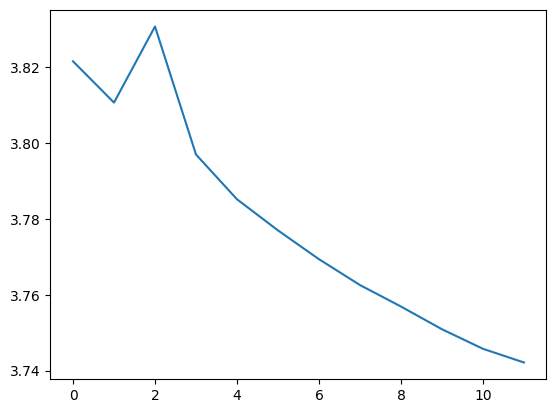

In [114]:
plt.plot(torch.tensor(lossi[:len(lossi) // 33123  * 33123 ]).view(-1,33123).mean(dim=-1))
plt.show()

In [12]:
class Translator:
    def __init__(self, source_tokenizer: Tokenizer, target_tokenizer: Tokenizer, model: TransformerEDM):
        self.source_tokenizer = source_tokenizer
        self.target_tokenizer = target_tokenizer
        self.pad_ind = self.target_tokenizer.token_to_id("[PAD]")
        self.unk_ind = self.target_tokenizer.token_to_id("[UNK]")
        self.sos_ind = self.target_tokenizer.token_to_id("[SOS]")
        self.eos_ind = self.target_tokenizer.token_to_id("[EOS]")
        self.model = model
        self.sequence_length = model.position.size(0)

    @torch.no_grad()
    def generate(self, source: str, device=DEVICE) -> str:
        source_ids = [self.sos_ind]
        source_ids.extend(self.source_tokenizer.encode(source).ids)
        source_ids.append(self.eos_ind)
        inputs = torch.tensor(source_ids, dtype=torch.long, device=device).unsqueeze(0)
        targets = torch.tensor([self.sos_ind], dtype=torch.long, device=device).unsqueeze(0)
        for i in range(self.sequence_length):
            output = self.model(inputs, targets)
            next_token = output[:, -1, :].argmax(dim=-1, keepdim=True)
            if next_token.item() == self.eos_ind:
                break
            targets = torch.cat([targets, next_token], dim=-1)
        target_ids = targets.squeeze(0).tolist()[1:]
        return "".join(self.target_tokenizer.id_to_token(x).lstrip("##") for x in target_ids)

In [151]:
translator = Translator(en_tokenizer, zh_tokenizer, model=model)

In [157]:
print(translator.generate("This cat is catching birds"))

这只猫在抓鸟。
